# **SM Reconstruction under Varying Retention Rates**

In [1]:
import scanpy as sc
import anndata
import pandas as pd
# import STMGraph_pyG0 as STMGraph
import SM2ST
# import SMLED
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.stats import pearsonr
os.environ['R_HOME'] = '/home/llx/software/minicbonda3/envs/pyg1/lib/R'

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **1 Read MSI**

In [2]:
# df_ms=pd.read_csv('/home/llx/project/jupyternotebook/1_pyg_backup/Data/MSD/mouse_brain_pen_dhb_50um_pixel_intensities.csv', skiprows=2,index_col=0)
df_ms=pd.read_csv('/home/llx/project/MSI_data/mouse_ito_30um/ito_30um_mad.csv',index_col=0)
df_ms

,x121_y1,x122_y1,x123_y1,x124_y1,x120_y2,x121_y2,x122_y2,x123_y2,x124_y2,x125_y2,...,x19_y180,x20_y180,x21_y180,x22_y180,x23_y180,x24_y180,x25_y180,x12_y181,x13_y181,x14_y181
152.020966,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
152.055574,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
154.024702,168.884988,173.589709,178.140641,0.000000,174.022542,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,141.996522,0.00000,152.399847
155.032674,914.838941,841.292449,685.393545,677.771875,864.347548,605.742957,471.56691,575.327534,615.13367,478.488232,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,474.338544,443.96218,673.394671
156.039791,175.582464,0.000000,0.000000,0.000000,173.381969,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002.575657,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
1003.580487,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
1006.491884,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000
1020.533017,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000


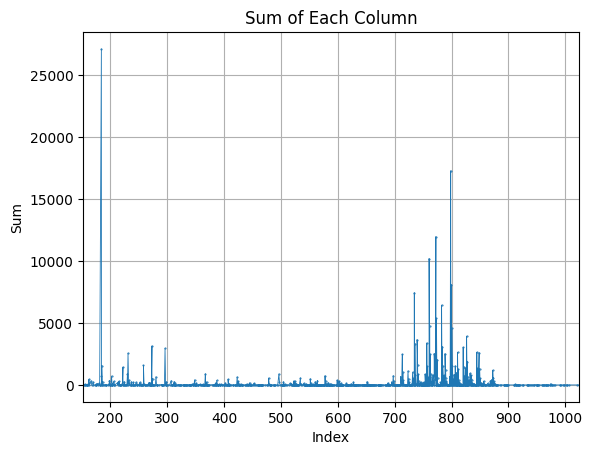

In [3]:
column_sums_i1 = df_ms.sum(axis = 1)/len(df_ms.columns)
column_sums_i1.index = column_sums_i1.index.astype(float)
# 绘制折线图
column_sums_i1.plot(kind='line', marker='.',linewidth=0.6, markersize=1)
plt.title('Sum of Each Column')
plt.xlabel('Index')
plt.ylabel('Sum')
plt.xticks(range(0, 1500, 100))  # 设置横轴刻度，每100个单位显示一个刻度
plt.xlim(column_sums_i1.index.min(), column_sums_i1.index.max())  # 设置横轴范围
# plt.xlim(850, 860)
plt.grid(True)
plt.show()

## **2 MSI constructs anndata**

In [4]:
def create_anndata_or(dataframe=None,pixel_size=1,mask_radio=0.5):
    
    df_ms_new=dataframe.iloc[:,:].T#4
    # Filter 0
    rows_all_zero = (df_ms_new == 0).all(axis=1)

    df_ms_new = df_ms_new[~rows_all_zero]
    df_ms_new = df_ms_new.apply(lambda x: x - x.min(), axis=0)
    # Collect all the coordinates and add them to the list
    rows = []
    cols = []
    for name in df_ms_new.index:
        x, y = name.split('_y')
        rows.append(int(x[1:]))
        cols.append(int(y))

    coordinates_df = pd.DataFrame({'array_row': rows, 'array_col': cols})
    coordinates_df.index = df_ms_new.index
    coordinates_physical_df = coordinates_df*pixel_size
    # Initialize the AnnData object
    index_df = pd.DataFrame(index=dataframe.index)
    adata = anndata.AnnData(X=df_ms_new.values, obs=coordinates_df, var=index_df)#4
    adata.obsm['spatial'] = coordinates_physical_df.values
    return adata

In [5]:
# step =30um
adata = create_anndata_or(dataframe=df_ms,pixel_size=30)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


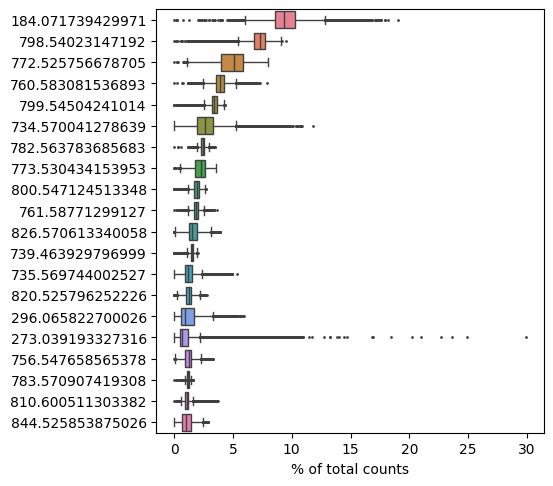

In [6]:
sc.pl.highest_expr_genes(adata, n_top=20, )

<Axes: title={'center': '844.525853875026'}, xlabel='spatial1', ylabel='spatial2'>

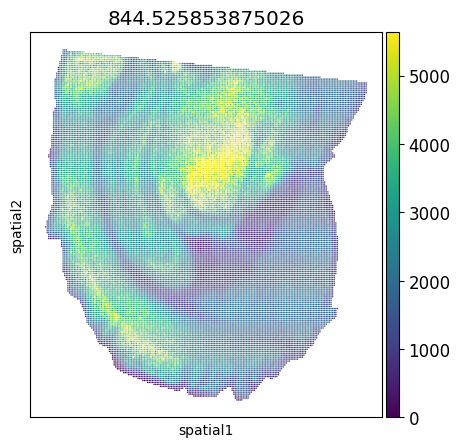

In [7]:
plot_gene = '844.525853875026'
fig, ax = plt.subplots(figsize=(5, 5))  # 
plt.rcParams['font.size'] = 12  # 
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '850.560353089783'}, xlabel='spatial1', ylabel='spatial2'>

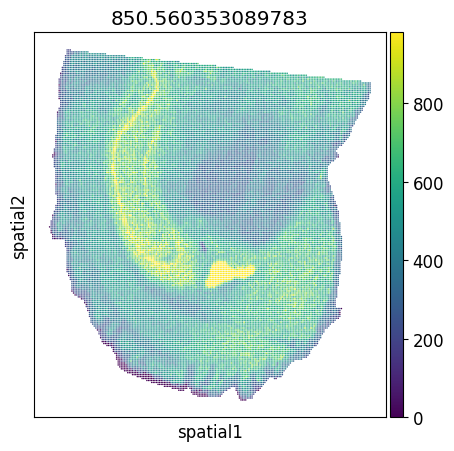

In [8]:
#new
plot_gene = '850.560353089783'#
fig, ax = plt.subplots(figsize=(5, 5))  # width = 5, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

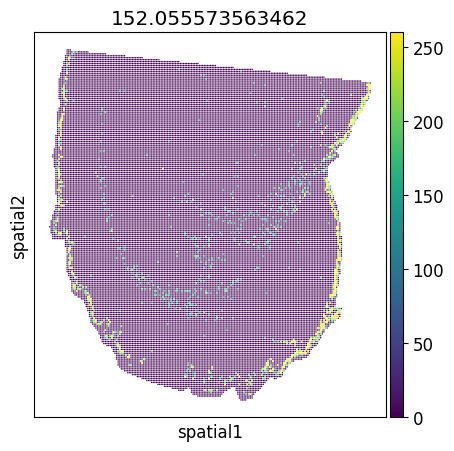

In [9]:
#new
plot_gene = '152.055573563462'
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

<Axes: title={'center': '844.525853875026'}, xlabel='spatial1', ylabel='spatial2'>

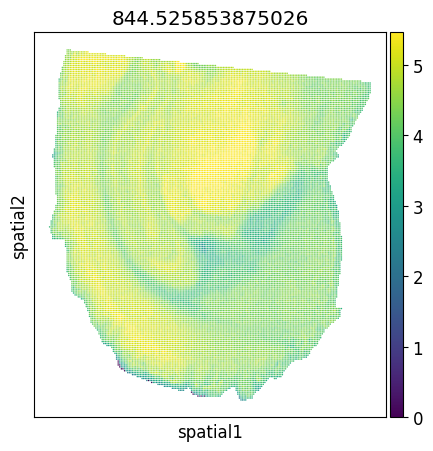

In [11]:
plot_gene = '844.525853875026'
fig, ax = plt.subplots(figsize=(5, 5))  # 
plt.rcParams['font.size'] = 12  # 
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '851.563432293921'}, xlabel='spatial1', ylabel='spatial2'>

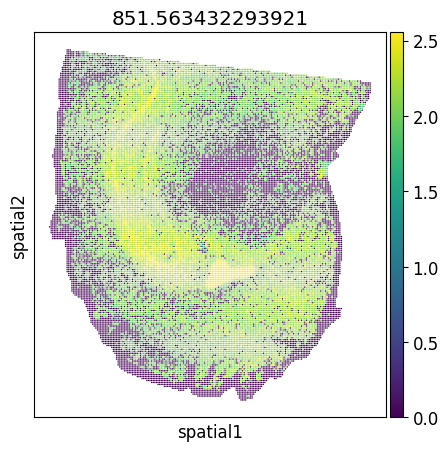

In [12]:
plot_gene = '851.563432293921'
fig, ax = plt.subplots(figsize=(5, 5))  # 
plt.rcParams['font.size'] = 12  # 
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

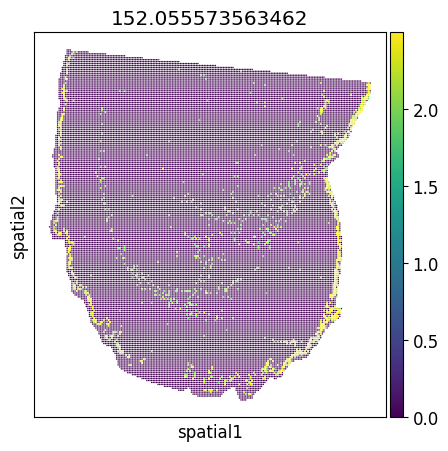

In [13]:
# new
plot_gene = '152.055573563462'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '259.113170463229'}, xlabel='spatial1', ylabel='spatial2'>

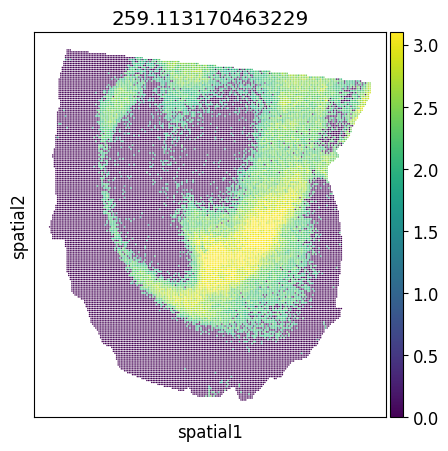

In [14]:
# new
plot_gene = '259.113170463229'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

## **3 Recovery the masked points**

In [15]:
#
adata_sample, adata_SMLED = SM2ST.train_SMLED(adata=adata, keep_ratio=0.3, coord_sf=2.0, train_epoch=10000, experiment='recovery',WMMSE = 1)# 0.3 0.7

<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

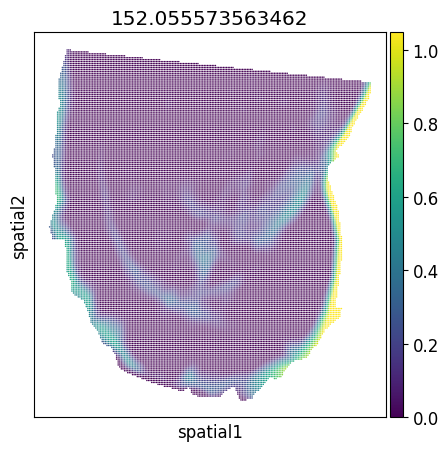

In [21]:
#new
plot_gene = '152.055573563462'
fig, ax = plt.subplots(figsize=(5, 5))  # width = 5, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 12
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

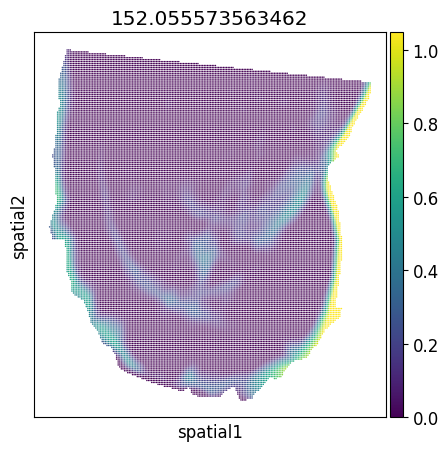

In [22]:
plot_gene = '152.055573563462'
fig, ax = plt.subplots(figsize=(5, 5))  # width = 5, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 12
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '152.055573563462'}, xlabel='spatial1', ylabel='spatial2'>

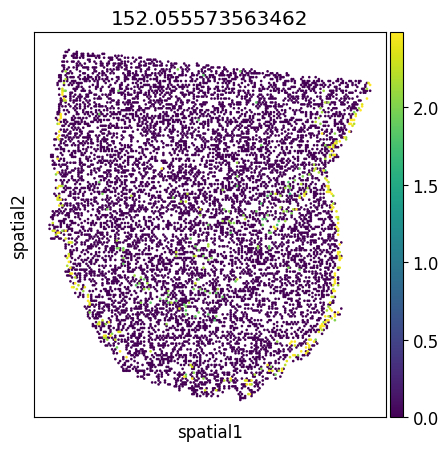

In [23]:
#new
plot_gene = '152.055573563462'
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_sample, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '844.525853875026'}, xlabel='spatial1', ylabel='spatial2'>

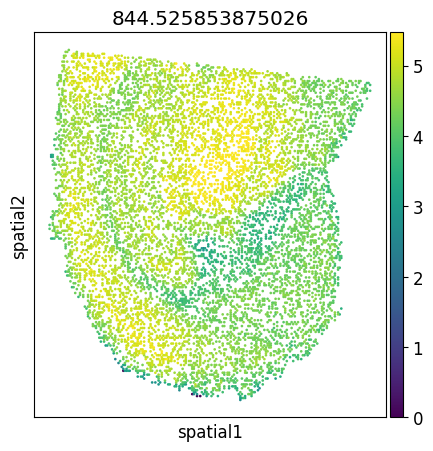

In [24]:
plot_gene = '844.525853875026'#
fig, ax = plt.subplots(figsize=(5, 5))  # 
plt.rcParams['font.size'] = 12  # 
sc.pl.embedding(adata_sample, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '733.612342692992'}, xlabel='spatial1', ylabel='spatial2'>

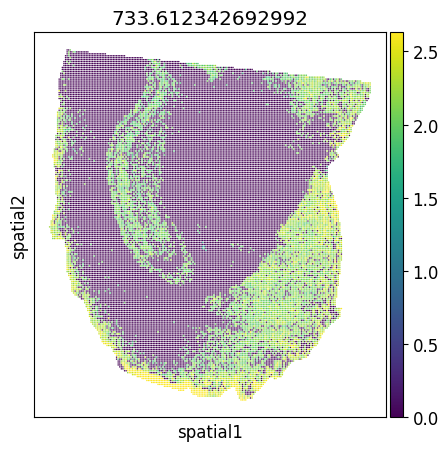

In [27]:
#new
plot_gene = '733.612342692992' # C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '733.612342692992'}, xlabel='spatial1', ylabel='spatial2'>

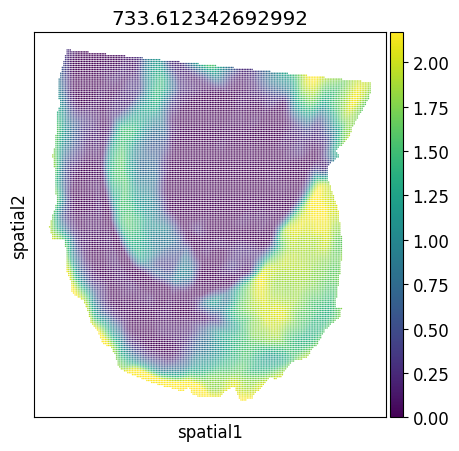

In [28]:
#new
plot_gene = '733.612342692992'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '851.563432293921'}, xlabel='spatial1', ylabel='spatial2'>

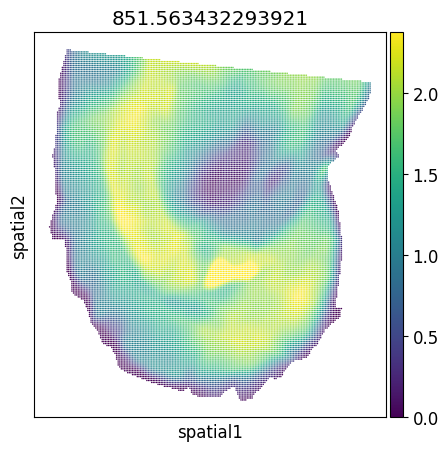

In [29]:
plot_gene = '851.563432293921'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # 
plt.rcParams['font.size'] = 12  #
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '844.525853875026'}, xlabel='spatial1', ylabel='spatial2'>

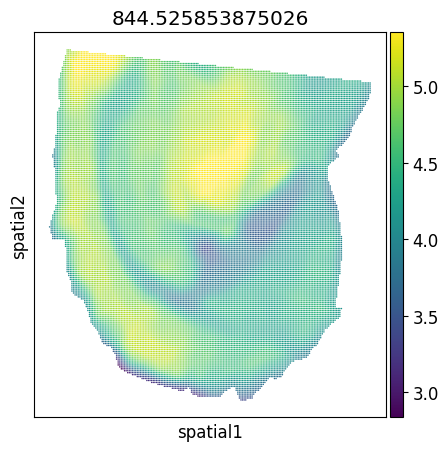

In [30]:
plot_gene = '844.525853875026'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # 
plt.rcParams['font.size'] = 12  # 
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '228.040519624895'}, xlabel='spatial1', ylabel='spatial2'>

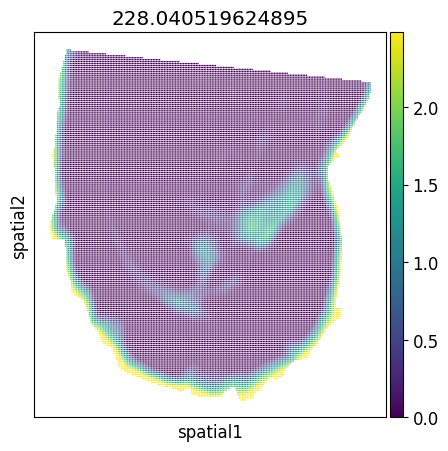

In [31]:
#new
plot_gene = '228.040519624895'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [40]:
# adata_SMLED.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_SMLED_wmse_mask03.h5ad')
# adata_sample.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_sample_wmse_mask03.h5ad')

In [41]:
adata_SMLED03 = adata_SMLED.copy()
adata_sample03 = adata_sample.copy()

In [36]:
adata_SMLED05 = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_SMLED.h5ad')
adata_sample05= sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_sample.h5ad')

In [39]:
adata_SMLED07 = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_SMLED_wmse_mask07.h5ad')
adata_sample07= sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_sample_wmse_mask07.h5ad')

In [49]:
adata_SMLED01 = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_SMLED_wmse_mask01.h5ad')
adata_sample01 = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_sample_wmse_mask01.h5ad')

In [57]:
adata

AnnData object with n_obs × n_vars = 27541 × 1389
    obs: 'array_row', 'array_col'
    uns: 'log1p'
    obsm: 'spatial'

In [59]:
adata_sample03

AnnData object with n_obs × n_vars = 8262 × 1389
    obs: 'array_row', 'array_col'
    uns: 'log1p'
    obsm: 'spatial'

## **4 Pearson correlation**

In [43]:
import numpy as np
from scipy.stats import pearsonr
# from scipy.stats import spearmanr
import pandas as pd
mask03 = ~adata_SMLED03.obs_names.isin(adata_sample03.obs_names)

A03 = adata_SMLED03[mask03, :].X.A
B03 = adata[mask03, :].X 

# Calculate the Pearson correlation coefficient and p-value between each row
r_values03 = []
p_values03 = []
for col1, col2 in zip(A03, B03):
    r_value, p_value = pearsonr(col1, col2)
    r_values03.append(r_value)
    p_values03.append(p_value)
# 计算皮尔森相关系数和p值
# r, p = pearsonr(A_flat, B_flat)

# print(f'Pearson Correlation Coefficient (r): {r}')
# print(f'P-value: {p}')

In [44]:
import numpy as np
from scipy.stats import pearsonr
# from scipy.stats import spearmanr
import pandas as pd
mask05 = ~adata_SMLED05.obs_names.isin(adata_sample05.obs_names)

A05 = adata_SMLED05[mask05, :].X.A
B05 = adata[mask05, :].X 

# Calculate the Pearson correlation coefficient and p-value between each row
r_values05 = []
p_values05 = []
for col1, col2 in zip(A05, B05):
    r_value, p_value = pearsonr(col1, col2)
    r_values05.append(r_value)
    p_values05.append(p_value)

In [45]:
import numpy as np
from scipy.stats import pearsonr
# from scipy.stats import spearmanr
import pandas as pd
mask07 = ~adata_SMLED07.obs_names.isin(adata_sample07.obs_names)

A07= adata_SMLED07[mask07, :].X.A
B07 = adata[mask07, :].X 

r_values07 = []
p_values07 = []
for col1, col2 in zip(A07, B07):
    r_value, p_value = pearsonr(col1, col2)
    r_values07.append(r_value)
    p_values07.append(p_value)

In [50]:
import numpy as np
from scipy.stats import pearsonr
# from scipy.stats import spearmanr
import pandas as pd

mask01 = ~adata_SMLED01.obs_names.isin(adata_sample01.obs_names)

A01= adata_SMLED01[mask01, :].X.A
B01 = adata[mask01, :].X

r_values01 = []
p_values01 = []
for col1, col2 in zip(A01, B01):
    r_value, p_value = pearsonr(col1, col2)
    r_values01.append(r_value)
    p_values01.append(p_value)

/tmp/ipykernel_2477126/3239645814.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([r_values, r_values2, r_values3, r_values4],
/tmp/ipykernel_2477126/3239645814.py:43: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [Rectangle((0, 0), 1, 1, color=color, edgecolor='black', label=label)


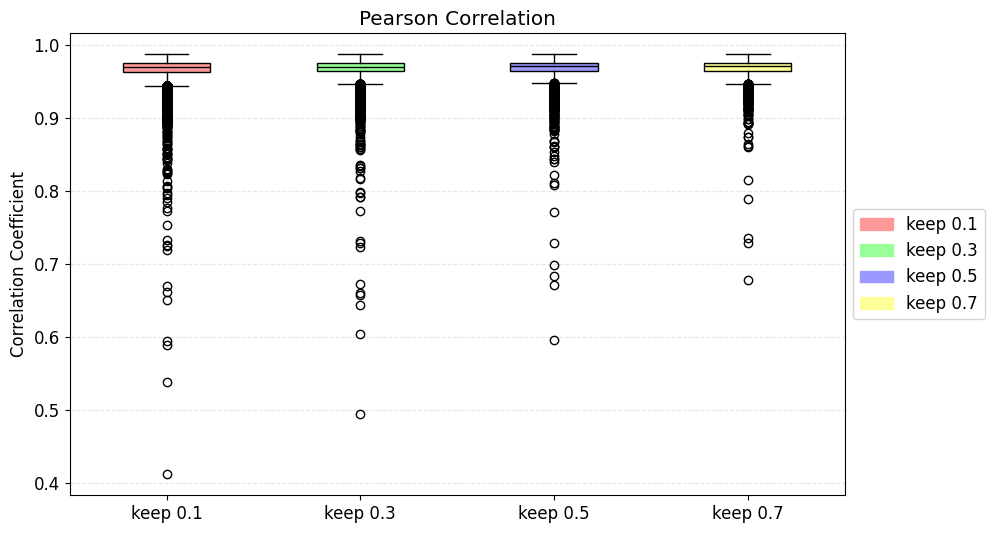

In [55]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np


r_values = r_values01 
r_values2 = r_values03
r_values3 = r_values05
r_values4 = r_values07
# ---------------------------------------------
# 1. Set labels
plt.figure(figsize=(10, 6))

box = plt.boxplot([r_values, r_values2, r_values3, r_values4], 
                  labels=['keep 0.1', 'keep 0.3', 'keep 0.5', 'keep 0.7'], 
                  patch_artist=True)
# 2. Set the color
colors = ['#FF9999', '#99FF99', '#9999FF', '#FFFF99'] 

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black') 

# 3. Set the color of the median line
for median in box['medians']:
    median.set_color('black')

# 4. Add titles and labels
plt.title('Pearson Correlation')
plt.ylabel('Correlation Coefficient')

# 5. Custom legend (expanded to 4 handles)
fig = plt.gcf()
ax = fig.gca()

# Create the handles for the custom legend, corresponding to 4 labels
labels = ['keep 0.1', 'keep 0.3', 'keep 0.5', 'keep 0.7']
handles = [Rectangle((0, 0), 1, 1, color=color, edgecolor='black', label=label) 
           for color, label in zip(colors, labels)]

# loc='center left': The lower left corner of the legend serves as the anchor point.
# bbox_to_anchor=(1, 0.5): Anchor point coordinates (x, y). When x = 1, 
# it indicates the rightmost edge of the drawing area; when y = 0.5, it means vertical centering.
# borderaxespad=0.: Padding between the legend and the coordinate axes
plt.legend(handles=handles, 
           loc='center left', 
           bbox_to_anchor=(1, 0.5), 
           borderaxespad=0.5)

plt.grid(axis='y', linestyle='--', alpha=0.3) # Optional: Add grid lines for better observation
plt.show()